# API使用

In [2]:
from sklearn.linear_model import LinearRegression

In [4]:
# 1.定义数据
# 自变量，每周学习时长，一般都为2维结构
X = [[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]]
# 因变量，数学考试成绩
y = [55, 65, 70, 75, 85, 50, 60, 72, 80, 58]

In [5]:
# 2.创建模型
lr = LinearRegression()

In [6]:
# 3.模型训练
lr.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# 4.打印模型参数
print(lr.coef_) # 斜率
print(lr.intercept_) # 截距

[2.87070855]
41.45069393718042


In [8]:
# 5.预测
print(lr.predict([[10]]))

[70.1577794]


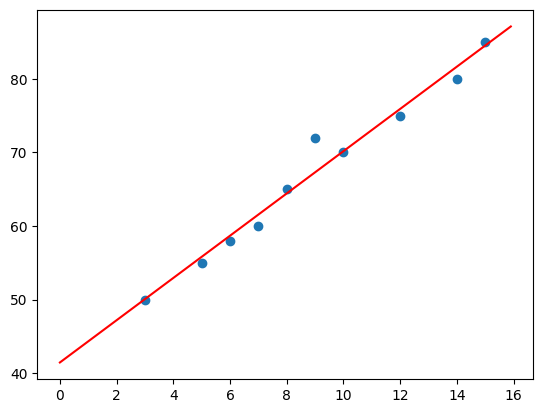

In [10]:
# 6.画图
import matplotlib.pyplot as plt
import numpy as np

x_line = np.arange(0, 16, 0.1).reshape(-1, 1) # n行1列
y_line = lr.predict(x_line)

plt.scatter(X, y)
plt.plot(x_line, y_line, c='r')
plt.show()

In [14]:
# 方差和协方差验证数学求解公式
x = np.array(X).reshape(-1)
cov = np.cov(x, y)
print(cov)
"""
x方差 协方差
协方差 y方差
"""
print(cov[0][1]/cov[0][0])

[[ 15.21111111  43.66666667]
 [ 43.66666667 128.66666667]]
2.8707085463842223


# 梯度下降法-手动

In [1]:
import numpy as np

In [2]:
# 1.定义数据
"""
X是有很多行、只有一列的矩阵
y也是同样的
"""
X = np.array([[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]])  # 自变量，每周学习时长
y = np.array([[55], [65], [70], [75], [85], [50], [60], [72], [80], [58]])  # 因变量，数学考试成绩
n = X.shape[0] # X有多少行，即得到有多少个元素

In [3]:
# 2.数据处理
X = np.hstack((np.ones((n,1)), X))

In [4]:
# 3.定义损失函数
def J(beta):
    return np.sum( (X @ beta -y) ** 2) / n
# 4.定义计算梯度函数
def gradient(beta):
    return X.T @ (X @ beta -y) / n *2

In [5]:
# 5.初始化参数及超参数
alpha = 0.01 #学习率
max_iter = 10000
step = 0
beta = np.array([[1],[1]])

In [6]:
# 6.重复迭代
# 存储轨迹
beta0 = []
beta1 = []

while (np.abs(grad := gradient(beta)) > 1e-10).any() and step < max_iter:
    beta0.append(beta[0,0])
    beta1.append(beta[1,0])
    beta = beta - alpha * grad

    # 每迭代10轮打印一次当前的参数值和损失值
    if step % 10 == 0:
        print(step, beta.ravel(), J(beta))

print(iter)

0 [ 2.142 11.676] 2589.9686919999995
0 [1.360832 2.312716] 2037.2863529184401
0 [ 2.26195191 10.48546158] 1613.751194840293
0 [1.69030071 3.31284653] 1289.1141485586663
0 [2.40680802 9.56870415] 1040.211546500253
0 [1.99544252 4.07364001] 849.3054687043048
0 [2.57042575 8.8616281 ] 702.8128390392966
0 [2.28164743 4.6511873 ] 590.3322124693511
0 [2.74810314 8.31514805] 503.89852349598766
0 [2.55304472 5.08844061] 437.41239912743396
0 [2.9362414  7.89167599] 386.2031471294455
0 [2.81279825 5.41829103] 346.69410803314554
0 [3.13208648 7.56242821] 316.14639365258
0 [3.06333253 5.6659252 ] 292.4626511922297
0 [3.33353119 7.30536299] 274.03679280779454
0 [3.30650595 5.85063001] 259.6389238696671
0 [3.53896369 7.10360139] 248.3272251359793
0 [3.54374337 5.98717447] 239.38047526707706
0 [3.74715145 6.94421799] 232.24637897639573
0 [3.77613762 6.08686801] 226.50199857327067
0 [3.95715236 6.81731475] 221.8234538510829
0 [4.00452729 6.15837082] 217.96271934329008
0 [4.16824674 6.71531198] 214.729

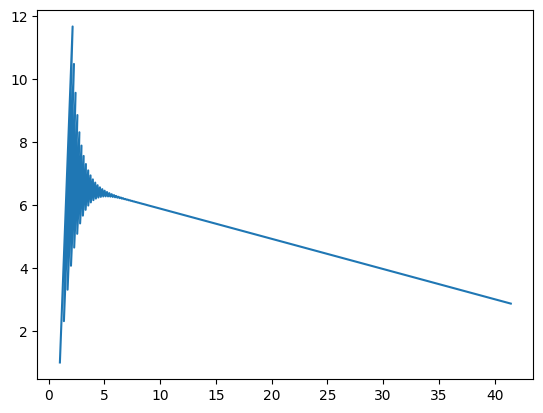

In [7]:
# 7.画图
import matplotlib.pyplot as plt
plt.plot(beta0, beta1)
plt.show()

# 随机梯度下降法-使用API

In [1]:
from sklearn.linear_model import SGDRegressor
import numpy as np

In [2]:
# 1.定义数据
X = np.array([[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]])  # 自变量，每周学习时长
y = np.array([55, 65, 70, 75, 85, 50, 60, 72, 80, 58])  # 因变量，数学考试成绩

In [3]:
# 2.创建模型
sgd = SGDRegressor(
    loss='squared_error',  # 损失函数
    max_iter=10000,  # 最大迭代次数
    learning_rate='constant',  # 学习率
    eta0=0.001,  # 固定学习率
    tol=1e-8 # 迭代终止条件
)

In [13]:
# 3.训练模型
sgd.fit(X, y)
print(sgd.coef_) # 回归系数-斜率
print(sgd.intercept_) # 截距

[3.63432987]
[33.28060164]


# 案例：广告投放效果预测

In [1]:
# 1.引入相关库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # 划分训练集和测试集
from sklearn.preprocessing import StandardScaler # 标准化缩放器
from sklearn.linear_model import LinearRegression,SGDRegressor # 线性回归模型：正规方程法和随机梯度下降模型
from sklearn.metrics import mean_squared_error # 均方误差损失函数

In [2]:
# 2.读入数据
data = pd.read_csv('2.测试数据/data/advertising.csv')
print(data.head())
"""
观察数据发现无NA值，这里就不进行去空值处理了，
但其第一列无实际意义，这里就去掉
"""
data = data.drop(['Unnamed: 0'],axis=1)
data.head()

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
# 3.划分数据集
X = data.iloc[:,:-1]
y = data.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(140, 3) (60, 3) (140,) (60,)


In [4]:
# 4.特征工程：标准化
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# 5.创建模型并训练
# 5.1:正规方程法
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)

print("斜率为:" + str(model_lr.coef_))
print("截距为:" + str(model_lr.intercept_))

# 5.2:随机梯度下降法
model_sgd = SGDRegressor()
model_sgd.fit(X_train,y_train)
print("斜率为:" + str(model_sgd.coef_))
print("截距为:" + str(model_sgd.intercept_))

斜率为:[3.68334078 2.90625242 0.14194772]
截距为:14.497142857142858
斜率为:[3.67883684 2.88844029 0.16077372]
截距为:[14.47615262]


In [6]:
# 6.预测
y_pred1 = model_lr.predict(X_test)
y_pred2 = model_sgd.predict(X_test)
print("正规方程法均方误差为:" + str(mean_squared_error(y_test,y_pred1)))
print("随机梯度下降法均方误差为:" + str(mean_squared_error(y_test,y_pred2)))

正规方程法均方误差为:3.7967972367152196
随机梯度下降法均方误差为:3.8035362274287405
